In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import norm
from arch import arch_model

plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [2]:
np.random.seed(42)
T = 10_000
ALPHA_PI = 0.05

mu = 0.05
phi = 0.7
omega = 0.02   # Small baseline
alpha = 0.1    # Sensitivity to shocks
beta = 0.85    # Persistence (this is the GARCH part - very high)

y = np.zeros(T)
epsilon = np.zeros(T)
sigma_sq = np.zeros(T)

sigma_sq[0] = omega / (1 - alpha - beta) # Unconditional variance
epsilon[0] = np.random.normal(0, np.sqrt(sigma_sq[0]))
y[0] = mu + epsilon[0]

In [3]:
for t in range(1, T):
    # Volatility depends on previous shock AND previous volatility
    sigma_sq[t] = omega + alpha * (epsilon[t-1]**2) + beta * sigma_sq[t-1]
    epsilon[t] = np.random.normal(0, np.sqrt(sigma_sq[t]))
    y[t] = mu + phi * y[t-1] + epsilon[t]

print("Simulation of AR(1)-GARCH(1,1) complete.")

Simulation of AR(1)-GARCH(1,1) complete.


In [4]:
# vol='Garch', p=1, q=1 is the standard (1,1) configuration
model = arch_model(y, mean='AR', lags=1, vol='Garch', p=1, q=1)
model_fit = model.fit(disp='off')
print(model_fit.summary())

                           AR - GARCH Model Results                           
Dep. Variable:                      y   R-squared:                       0.472
Mean Model:                        AR   Adj. R-squared:                  0.472
Vol Model:                      GARCH   Log-Likelihood:               -9224.43
Distribution:                  Normal   AIC:                           18458.9
Method:            Maximum Likelihood   BIC:                           18494.9
                                        No. Observations:                 9999
Date:                Thu, Apr 02 2026   Df Residuals:                     9997
Time:                        07:17:26   Df Model:                            2
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const          0.0522  5.898e-03      8.855  8.345e-19 [4.

In [5]:
# Extract fitted components for t=1...T-1
mu_hat = model_fit.params['Const']
phi_hat = model_fit.params['y[1]']
y_hat = mu_hat + phi_hat * y[:-1]
y_std = model_fit.conditional_volatility[1:]
y_true = y[1:]

z = norm.ppf(1 - ALPHA_PI / 2)
lower, upper = y_hat - z * y_std, y_hat + z * y_std

# Baselines
def get_metrics(y_true, l, u, alpha=0.05):
    cov = np.mean((y_true >= l) & (y_true <= u))
    wid = np.mean(u - l)
    is_val = np.mean((u - l) + (2/alpha)*np.maximum(l-y_true, 0) + (2/alpha)*np.maximum(y_true-u, 0))
    return cov, wid, is_val

res = {
    "AR(1)-GARCH(1,1)": get_metrics(y_true, lower, upper, ALPHA_PI),
    "Baseline: Global Std": get_metrics(y_true, np.mean(y_true) - z*np.std(y_true), np.mean(y_true) + z*np.std(y_true), ALPHA_PI)
}

--------------------------------------------------------------------------------
Model Profile                  |   Coverage |  Avg Width | IS (↓ lower)
--------------------------------------------------------------------------------
AR(1)-GARCH(1,1)               |     0.9502 |     2.4252 |       2.8997
Baseline: Global Std           |     0.9476 |     3.3894 |       4.3609
--------------------------------------------------------------------------------


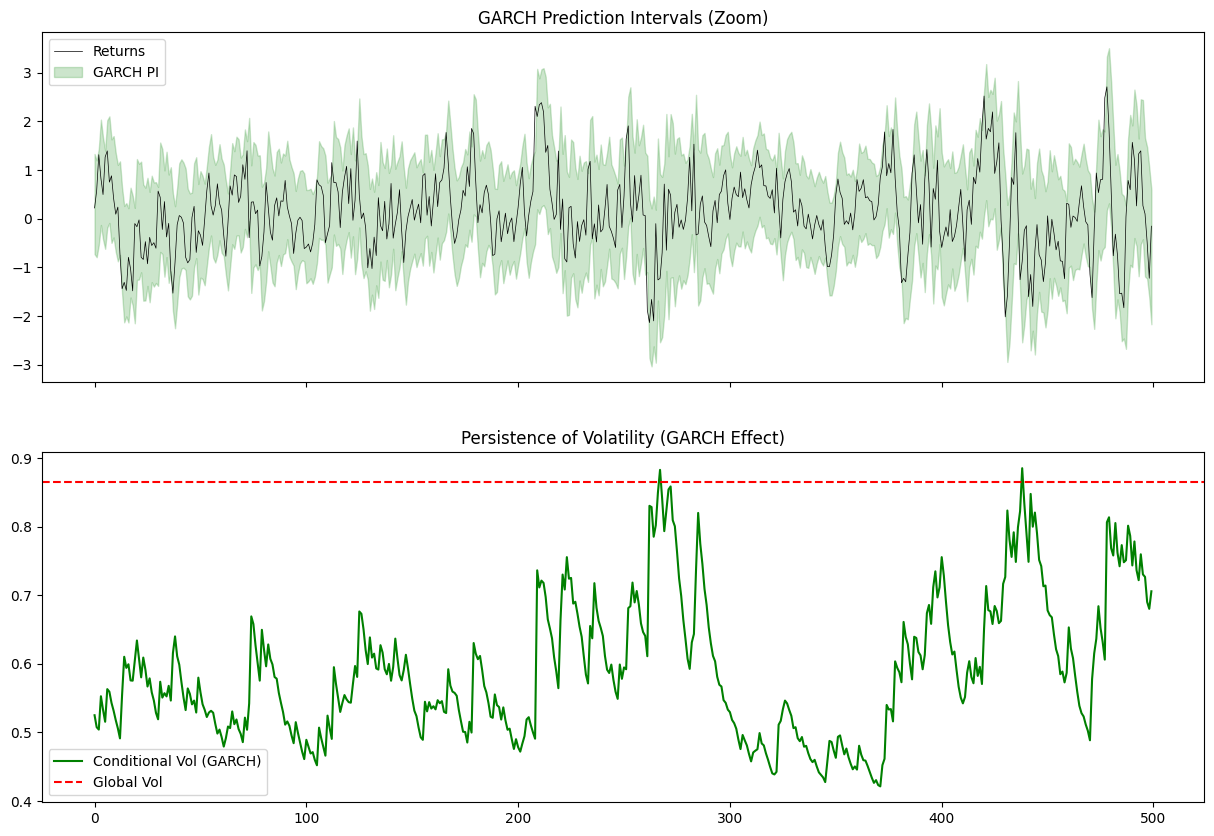

In [6]:
# -----------------------------------------------------------------
# SUMMARY TABLE
# -----------------------------------------------------------------
print("-" * 80)
print(f"{'Model Profile':<30} | {'Coverage':>10} | {'Avg Width':>10} | {'IS (↓ lower)':>12}")
print("-" * 80)
for name, metrics in res.items():
    cov, wid, is_val = metrics
    print(f"{name:<30} | {cov:>10.4f} | {wid:>10.4f} | {is_val:>12.4f}")
print("-" * 80)

# -----------------------------------------------------------------
# PLOTS
# -----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
ax1.plot(y_true[:500], color='black', lw=0.5, label='Returns')
ax1.fill_between(range(500), lower[:500], upper[:500], color='green', alpha=0.2, label='GARCH PI')
ax1.set_title("GARCH Prediction Intervals (Zoom)")
ax1.legend()

ax2.plot(y_std[:500], color='green', label='Conditional Vol (GARCH)')
ax2.axhline(np.std(y_true), color='red', linestyle='--', label='Global Vol')
ax2.set_title("Persistence of Volatility (GARCH Effect)")
ax2.legend()
plt.show()